In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    LabelEncoder,
)

from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
)

import joblib

Matplotlib is building the font cache; this may take a moment.


In [2]:
bank_marketing = fetch_ucirepo(id=222)

X = bank_marketing.data.features
y = bank_marketing.data.targets.squeeze()

print("Dimensión de X:", X.shape)
print("Dimensión de y:", y.shape)

X.head()

Dimensión de X: (45211, 16)
Dimensión de y: (45211,)


,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN


In [3]:
df = X.copy()
df["target"] = y

df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,target
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN,no
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN,no
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN,no
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN,no


In [4]:
df.info()
df["target"].value_counts(normalize=True)

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   age          45211 non-null  int64
 1   job          44923 non-null  str  
 2   marital      45211 non-null  str  
 3   education    43354 non-null  str  
 4   default      45211 non-null  str  
 5   balance      45211 non-null  int64
 6   housing      45211 non-null  str  
 7   loan         45211 non-null  str  
 8   contact      32191 non-null  str  
 9   day_of_week  45211 non-null  int64
 10  month        45211 non-null  str  
 11  duration     45211 non-null  int64
 12  campaign     45211 non-null  int64
 13  pdays        45211 non-null  int64
 14  previous     45211 non-null  int64
 15  poutcome     8252 non-null   str  
 16  target       45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 5.9 MB


target
no     0.883015
yes    0.116985
Name: proportion, dtype: float64

In [5]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

print("Variables numéricas:", numeric_features)
print("Variables categóricas:", categorical_features)

target_encoder = LabelEncoder()
y_encoded = target_encoder.fit_transform(y)

print("Clases:", list(target_encoder.classes_))
print("Ejemplo y codificado:", y_encoded[:10])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

C:\Users\ALEX\AppData\Local\Temp\ipykernel_15592\611227312.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()


Variables numéricas: ['age', 'balance', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous']
Variables categóricas: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
Clases: ['no', 'yes']
Ejemplo y codificado: [0 0 0 0 0 0 0 0 0 0]


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.30,
    random_state=42,
    stratify=y_encoded,
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (31647, 16)
Test: (13564, 16)


In [7]:
mlp_model = MLPClassifier(
    hidden_layer_sizes=(16, 8),
    activation="relu",
    solver="adam",
    max_iter=300,
    random_state=42,
    early_stopping=True,
)

pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", mlp_model),
    ]
)

pipeline.fit(X_train, y_train)

print("Entrenamiento finalizado.")

Entrenamiento finalizado.


In [8]:
y_pred = pipeline.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

print(classification_report(y_test, y_pred, target_names=target_encoder.classes_))

Accuracy : 0.9005
Precision: 0.6184
Recall   : 0.3900
F1-score : 0.4784
              precision    recall  f1-score   support

          no       0.92      0.97      0.94     11977
         yes       0.62      0.39      0.48      1587

    accuracy                           0.90     13564
   macro avg       0.77      0.68      0.71     13564
weighted avg       0.89      0.90      0.89     13564



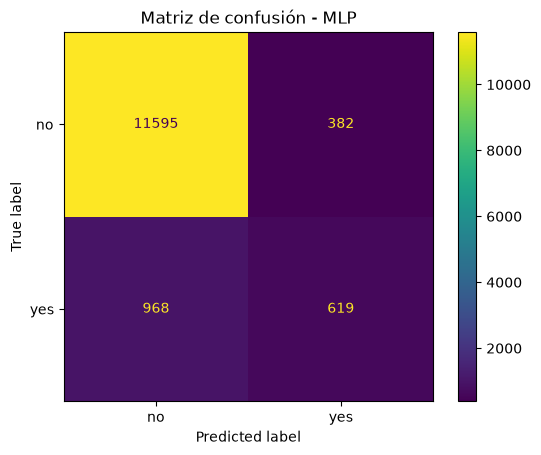

In [9]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=target_encoder.classes_,
)

plt.title("Matriz de confusión - MLP")
plt.show()

In [12]:
architectures = [
    (8,),
    (16, 8),
    (32, 16, 8),
]

results = []

for architecture in architectures:
    model = MLPClassifier(
        hidden_layer_sizes=architecture,
        activation="relu",
        solver="adam",
        max_iter=300,
        random_state=42,
        early_stopping=True,
    )

    pipe = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model),
        ]
    )

    pipe.fit(X_train, y_train)
    predictions = pipe.predict(X_test)

    results.append(
        {
            "architecture": str(architecture),
            "accuracy": accuracy_score(y_test, predictions),
            "precision": precision_score(y_test, predictions),
            "recall": recall_score(y_test, predictions),
            "f1_score": f1_score(y_test, predictions),
            "iterations": pipe.named_steps["model"].n_iter_,
        }
    )

results_df = pd.DataFrame(results)

results_df

,architecture,accuracy,precision,recall,f1_score,iterations
0,"(8,)",0.902757,0.646608,0.372401,0.472611,16
1,"(16, 8)",0.900472,0.618382,0.390044,0.478362,14
2,"(32, 16, 8)",0.905264,0.625207,0.475110,0.539921,31


In [13]:
print(results_df)

  architecture  accuracy  precision    recall  f1_score  iterations
0         (8,)  0.902757   0.646608  0.372401  0.472611          16
1      (16, 8)  0.900472   0.618382  0.390044  0.478362          14
2  (32, 16, 8)  0.905264   0.625207  0.475110  0.539921          31


# 12. Reto MIT

## Comparación de arquitecturas

Como parte del reto, se entrenaron tres arquitecturas diferentes de Perceptrón Multicapa con el objetivo de analizar cómo influye el número de capas y neuronas en el desempeño del modelo.

Los resultados obtenidos fueron los siguientes:

| Arquitectura | Accuracy | Precision | Recall | F1-score |
|--------------|----------|-----------|--------|----------|
| (8,) | 0.9028 | 0.6466 | 0.3724 | 0.4726 |
| (16, 8) | 0.9005 | 0.6184 | 0.3900 | 0.4784 |
| (32, 16, 8) | **0.9053** | **0.6252** | **0.4751** | **0.5400** |

Al comparar las tres arquitecturas, se observa que la configuración **(32, 16, 8)** obtuvo el mejor rendimiento general. Aunque la arquitectura **(8,)** presentó una mayor precisión, su capacidad para identificar correctamente a los clientes que aceptarían el depósito fue menor, lo que se refleja en un recall y un F1-score inferiores. Por otro lado, la arquitectura **(16, 8)** mostró un comportamiento intermedio, pero sin superar los resultados de la arquitectura más profunda.

## Arquitectura seleccionada para producción

Si fuera el ingeniero responsable del banco, implementaría la arquitectura **(32, 16, 8)**. Esta configuración obtuvo el mejor Accuracy (0.9053), el mayor Recall (0.4751) y el mejor F1-score (0.5400), demostrando un mejor equilibrio entre identificar correctamente a los clientes interesados y mantener un buen desempeño general. Aunque requiere un poco más de tiempo de entrenamiento, la mejora obtenida justifica su elección y el riesgo de sobreajuste se mantiene controlado gracias al uso de **Early Stopping**.

En conclusión, la arquitectura **(32, 16, 8)** sería la alternativa más adecuada para un entorno de producción, ya que ofrece el mejor balance entre rendimiento, capacidad de generalización y complejidad del modelo.

# 11. Preguntas de análisis

### 1. ¿Qué diferencia existe entre un perceptrón simple y un perceptrón multicapa?

El perceptrón simple cuenta con una sola capa de salida y solo puede resolver problemas donde los datos son linealmente separables. En cambio, el perceptrón multicapa incorpora una o más capas ocultas que le permiten aprender relaciones más complejas y resolver problemas de clasificación con mayor precisión.

---

### 2. ¿Qué función cumplen las capas ocultas?

Las capas ocultas permiten que la red neuronal aprenda patrones y relaciones entre las variables de entrada. Gracias a ellas, el modelo puede identificar información más compleja y mejorar la calidad de las predicciones.

---

### 3. ¿Por qué fue necesario convertir variables categóricas a variables numéricas?

Fue necesario porque las redes neuronales solo trabajan con datos numéricos. Por ello, las variables categóricas se transformaron mediante One-Hot Encoding para que el modelo pudiera utilizarlas durante el entrenamiento sin alterar su significado.

---

### 4. ¿Por qué se estandarizan las variables numéricas antes de entrenar una red neuronal?

La estandarización permite que todas las variables tengan una escala similar, evitando que unas influyan más que otras durante el aprendizaje. Esto facilita el entrenamiento y mejora la convergencia del modelo.

---

### 5. ¿Qué significa `hidden_layer_sizes=(16, 8)`?

Significa que la red neuronal está formada por dos capas ocultas. La primera contiene 16 neuronas y la segunda 8 neuronas, las cuales trabajan de manera conjunta para aprender los patrones presentes en los datos.

---

### 6. ¿Qué métrica considera más importante para este caso: Accuracy, Precision, Recall o F1-score? Justifique.

Considero que el **F1-score** es la métrica más importante, ya que el conjunto de datos presenta un desbalance entre clientes que aceptan y no aceptan el depósito. Esta métrica combina la precisión y el recall, proporcionando una evaluación más equilibrada del rendimiento del modelo.

---

### 7. ¿Qué riesgos existen si el banco usa este modelo para tomar decisiones comerciales reales?

El principal riesgo es que el modelo pueda clasificar incorrectamente a algunos clientes. Esto podría hacer que el banco deje de contactar a personas con alta probabilidad de aceptar la oferta o invierta recursos en clientes que probablemente no estén interesados.

---

### 8. ¿Por qué un modelo más grande no siempre es mejor?

Porque una red con más capas y neuronas no garantiza mejores resultados. Un modelo demasiado complejo puede requerir más tiempo de entrenamiento, consumir más recursos y aumentar el riesgo de sobreajuste, afectando su capacidad para generalizar con nuevos datos.